# Evaluation: Qwen2.5-Coder-32B for Solana Vulnerability Detection

This notebook evaluates Qwen2.5-Coder-32B-Instruct across 4 configurations to measure the impact of Fine-Tuning and RAG on vulnerability detection performance.

The 4 configurations:
1. **Qwen-Base (no RAG)** — baseline, unmodified model
2. **Qwen-Base + RAG** — base model with retrieval-augmented context
3. **Qwen-FT (no RAG)** — fine-tuned model, direct prompting
4. **Qwen-FT + RAG** — fine-tuned model with RAG context

Each configuration is tested on 59 unseen contracts. We compute Accuracy, Precision, Recall, and F1-Score.

**Reference:** Boi & Esposito (2025), Tortora (2025)

**Hardware:** NVIDIA RTX A6000 (48GB VRAM), CUDA 12.6

## 1. Environment & Path Setup

In [1]:
import os, json, re, gc, time
import torch
import numpy as np
from collections import defaultdict

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# Paths
BASE_DIR = os.path.expanduser("~/NotebookProjects/bboi/Mustafa_LL")
REPO_DIR = os.path.join(BASE_DIR, "LLM-Contract-Analyzer")
TEST_DIR = os.path.join(REPO_DIR, "data", "test_set")
KB_DIR = os.path.join(REPO_DIR, "data", "knowledge_base")
FT_MODEL_DIR = os.path.join(BASE_DIR, "models", "Qwen2.5-Coder-32B-Solana-Audit")
RESULTS_DIR = os.path.join(BASE_DIR, "results", "qwen2.5-coder-32b")
os.makedirs(RESULTS_DIR, exist_ok=True)

VULN_INFO_PATH = os.path.join(KB_DIR, "vulnerability_info.json")
RAG_CONTRACTS_PATH = os.path.join(KB_DIR, "rag_contracts.jsonl")

# Verify all paths exist
for path, name in [
    (TEST_DIR, "Test set"),
    (VULN_INFO_PATH, "Vulnerability info"),
    (RAG_CONTRACTS_PATH, "RAG contracts"),
    (FT_MODEL_DIR, "Fine-tuned model"),
]:
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"{name}: {status} ({path})")

# Load test files
test_files = sorted([
    os.path.join(TEST_DIR, f) for f in os.listdir(TEST_DIR)
    if f.startswith("solana_") and f.endswith(".json")
])
print(f"\nTest contracts found: {len(test_files)}")

PyTorch: 2.10.0+cu126
CUDA: True
GPU: NVIDIA RTX A6000
VRAM: 47.4 GB
Test set: OK (/home/habes/NotebookProjects/bboi/Mustafa_LL/LLM-Contract-Analyzer/data/test_set)
Vulnerability info: OK (/home/habes/NotebookProjects/bboi/Mustafa_LL/LLM-Contract-Analyzer/data/knowledge_base/vulnerability_info.json)
RAG contracts: OK (/home/habes/NotebookProjects/bboi/Mustafa_LL/LLM-Contract-Analyzer/data/knowledge_base/rag_contracts.jsonl)
Fine-tuned model: OK (/home/habes/NotebookProjects/bboi/Mustafa_LL/models/Qwen2.5-Coder-32B-Solana-Audit)

Test contracts found: 59


## 2. Define Evaluation Prompts

Same prompts used in Phase 1 (LLaMA evaluation) for fair comparison.

In [2]:
SYSTEM_PROMPT_NO_RAG = """You are an expert smart contract security auditor specialized in the Solana blockchain and Rust.
Your task is to analyze Rust code precisely and systematically to identify security vulnerabilities.

Required behavior:
- Perform a structured reasoning phase inside <think>...</think> tags.
- After </think>, provide the final judgment inside <final>...</final> tags with this structure:
  - A short summary sentence.
  - ### Vulnerability: <name or "Not Vulnerable">
  - ### Explanation: <concise cause and how it can be exploited>
  - ### Risk: <severity (Critical/High/Medium/Low) and short impact statement>

If no vulnerability is found, write "### Vulnerability: Not Vulnerable".
Do NOT include any extra commentary outside these tags.""".strip()

USER_PROMPT_NO_RAG = """Please perform a detailed security analysis of the following Solana smart contract.
Carefully examine its logic, identify any potential vulnerabilities:

Contract Code:

```rust
{code}
```""".strip()

SYSTEM_PROMPT_RAG = """You are an expert smart contract security auditor specialized in the Solana blockchain and Rust.
Your task is to analyze Rust code precisely and systematically to identify security vulnerabilities, leveraging additional contextual information retrieved via RAG.

Required behavior:
- Perform a structured reasoning phase inside <think>...</think> tags.
  - For each RAG-suggested vulnerability, check whether the code enforces the required security invariant.
  - Also remain open to detecting other vulnerabilities not present in the RAG list.
- After </think>, provide the final judgment inside <final>...</final> tags with this structure:
  - A short summary sentence.
  - ### Vulnerability: <name or "Not Vulnerable">
  - ### Explanation: <concise cause and how it could be exploited>
  - ### Risk: <severity (Critical/High/Medium/Low) and short impact statement>

If no vulnerability is found, write "### Vulnerability: Not Vulnerable".
Do NOT include any extra commentary outside these tags.""".strip()

USER_PROMPT_RAG = """Here is a vulnerability checklist (from RAG) with priority guidance.
Use it to steer your audit, but also look for issues beyond this list.

{checklist}

Now perform a detailed security analysis of the following Solana smart contract:

Contract Code:

```rust
{code}
```""".strip()

SYSTEM_PROMPT_DESCRIPTION = """You are an expert smart contract security auditor specialized in Solana and Rust.
Describe the given Solana program with exactly these 3 sections:

### Contract type:
State whether this is a "Solana program instruction handler".

### Contract Purpose
One short paragraph stating the primary objective.

### Functional Description
Step-by-step description of the execution logic. Be explicit about which accounts are validated and how.
Do not include variable names or code syntax.""".strip()

print("Prompts defined.")

Prompts defined.


## 3. Response Parser

Extracts the vulnerability verdict from the model's `<final>` block.

In [3]:
KNOWN_VULNERABILITIES = [
    "Missing Key Check", "Access Control",
    "Type Confusion", "Input Validation",
    "CPI Reentrancy", "Reentrancy",
    "Unchecked External Calls", "Unchecked Calls",
    "Integer Overflow", "Integer Underflow", "Integer Flow",
    "Bump Seed", "Bump Seed Canonicalization",
    "Denial of Service", "DoS",
    "Not Vulnerable", "No security risk", "No vulnerabilities", "None detected",
]

def parse_response(response):
    """Extract vulnerability verdict from the <final> block."""
    match = re.search(r"<final>\s*(.*?)\s*</final>", response, re.IGNORECASE | re.DOTALL)
    if not match:
        return False, []
    content = match.group(1).strip().lower()
    found = [v for v in KNOWN_VULNERABILITIES if v.lower() in content]
    return (True, found) if found else (False, [])

VULN_DISPLAY = {
    "missing_key_check": "Missing Key Check",
    "type_confusion": "Type Confusion",
    "cpi_reentrancy": "CPI Reentrancy",
    "unchecked_calls": "Unchecked External Calls",
    "integer_overflow": "Integer Overflow",
    "bump_seed": "Bump Seed",
    "dos": "Denial of Service",
    "not_vulnerable": "Not Vulnerable",
}

print("Parser ready.")

Parser ready.


## 4. RAG Pipeline

Same RAG system as Phase 1: generate description → embed → find similar → build checklist.

In [4]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Loading embedding model...")
embed_model = SentenceTransformer("hkunlp/instructor-xl")
print("Embedding model loaded.")

with open(VULN_INFO_PATH, "r", encoding="utf-8") as f:
    vuln_info = json.load(f)

rag_contracts = []
with open(RAG_CONTRACTS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        rag_contracts.append(json.loads(line))

print(f"RAG knowledge base: {len(rag_contracts)} contracts, {len(vuln_info)} vulnerability types")

instruction = "Represent the following functional description of a Solana smart contract, written in Rust:"
rag_embeddings = []
for contract in rag_contracts:
    emb = embed_model.encode([instruction, contract["description"]])
    rag_embeddings.append(emb)
rag_embeddings = np.array(rag_embeddings)
print(f"Embeddings computed: {rag_embeddings.shape}")


def search_similar_contracts(query_description, top_k=None):
    """Find the most similar contracts in the knowledge base."""
    query_emb = embed_model.encode([instruction, query_description]).reshape(1, -1)
    results = []
    for i, emb in enumerate(rag_embeddings):
        sim = cosine_similarity(emb.reshape(1, -1), query_emb)[0][0]
        results.append({
            "vulnerability": rag_contracts[i]["vulnerability"],
            "vulnerable_part": rag_contracts[i]["vulnerable_part"],
            "similarity": f"{sim:.4f}",
        })
    results.sort(key=lambda x: x["similarity"], reverse=True)
    seen = set()
    unique_results = []
    for r in results:
        if r["vulnerability"] not in seen:
            seen.add(r["vulnerability"])
            unique_results.append(r)
    return unique_results


def build_rag_checklist(similar_contracts, num_detailed=3):
    """Build a prioritized vulnerability checklist from retrieval results."""
    checklist = ""
    for i, contract in enumerate(similar_contracts):
        vuln_key = contract["vulnerability"]
        if vuln_key not in vuln_info:
            continue
        info = vuln_info[vuln_key]
        score = contract["similarity"]
        if i < num_detailed:
            checklist += f"""\n    {i+1}. **{info['name']}** ({score})\n        - Description: {info['description']}\n        - Preconditions: {info['precondition']}\n        - Security check: {info['security_check']}\n        - Example vulnerable pattern:\n          ```rust\n    {contract['vulnerable_part'].strip()}\n          ```\n"""
        else:
            checklist += f"""\n    {i+1}. **{info['name']}** ({score})\n"""
    return checklist

print("RAG pipeline ready.")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu126).


Loading embedding model...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Embedding model loaded.
RAG knowledge base: 37 contracts, 7 vulnerability types
Embeddings computed: (37, 2, 768)
RAG pipeline ready.


## 5. Model Loading Functions

In [5]:
from unsloth import FastLanguageModel

def load_base_model():
    """Load the original Qwen2.5-Coder-32B-Instruct without fine-tuning."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name="unsloth/Qwen2.5-Coder-32B-Instruct",
        max_seq_length=2048,
        dtype=None,
        load_in_4bit=True,
    )
    FastLanguageModel.for_inference(model)
    return model, tokenizer

def load_finetuned_model():
    """Load the fine-tuned model from the local adapter directory."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=FT_MODEL_DIR,
        max_seq_length=2048,
        dtype=None,
        load_in_4bit=True,
    )
    FastLanguageModel.for_inference(model)
    return model, tokenizer

def unload_model(model, tokenizer):
    """Free GPU memory before loading the next model."""
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()

def generate_response(model, tokenizer, messages, max_tokens=1024):
    """Generate a response from the model given a list of messages."""
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    outputs = model.generate(
        input_ids=inputs, max_new_tokens=max_tokens, temperature=0.6, top_p=0.95
    )
    return tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True)

print("Model loading functions ready.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/tmp/ipykernel_1766764/2953169024.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Model loading functions ready.


## 6. Evaluation & Metrics Functions

In [6]:
VULNERABILITY_ALIASES = {
    "Missing Key Check": ["missing key check", "access control"],
    "Type Confusion": ["type confusion", "input validation"],
    "CPI Reentrancy": ["cpi reentrancy", "cpi", "reentrancy"],
    "Unchecked External Calls": ["unchecked external calls", "unchecked calls"],
    "Integer Overflow": ["integer overflow", "integer underflow", "integer flow"],
    "Bump Seed": ["bump seed", "bump seed canonicalization"],
    "Denial of Service": ["denial of service", "dos"],
    "Not Vulnerable": ["not vulnerable", "no security risk", "no vulnerabilities", "none detected"],
}

GROUND_TRUTH_MAP = {
    "integer_flow": "Integer Overflow",
    "cpi": "CPI Reentrancy",
}


def normalize_predictions(predictions):
    """Map raw predictions to canonical vulnerability names."""
    canonical_set = set()
    for pred in predictions:
        pred_lower = pred.lower().strip()
        for canonical, aliases in VULNERABILITY_ALIASES.items():
            if pred_lower in aliases:
                canonical_set.add(canonical)
                break
    return canonical_set


def evaluate_config(model, tokenizer, test_files, use_rag=False, config_name=""):
    """Run evaluation on all test contracts for one configuration."""
    results = []
    total = len(test_files)

    for idx, test_file in enumerate(test_files):
        with open(test_file, "r", encoding="utf-8") as f:
            test_data = json.load(f)

        code = test_data["smart_contract"]
        ground_truth = test_data["vulnerability"]
        truth_display = VULN_DISPLAY.get(ground_truth, ground_truth)

        if use_rag:
            desc_messages = [
                {"role": "system", "content": SYSTEM_PROMPT_DESCRIPTION},
                {"role": "user", "content": f"Describe this Solana contract:\n\n```rust\n{code}\n```"},
            ]
            description = generate_response(model, tokenizer, desc_messages, max_tokens=512)
            similar = search_similar_contracts(description)
            checklist = build_rag_checklist(similar)
            messages = [
                {"role": "system", "content": SYSTEM_PROMPT_RAG},
                {"role": "user", "content": USER_PROMPT_RAG.format(checklist=checklist, code=code)},
            ]
        else:
            messages = [
                {"role": "system", "content": SYSTEM_PROMPT_NO_RAG},
                {"role": "user", "content": USER_PROMPT_NO_RAG.format(code=code)},
            ]

        found_vulns = []
        for attempt in range(3):
            response = generate_response(model, tokenizer, messages)
            success, found_vulns = parse_response(response)
            if success:
                break

        results.append({
            "file": os.path.basename(test_file),
            "ground_truth": truth_display,
            "predictions": found_vulns,
            "response": response,
        })

        pred_str = ", ".join(found_vulns) if found_vulns else "PARSE_FAIL"
        status = "MATCH" if truth_display in [normalize_predictions(found_vulns)] else ""
        print(f"  [{idx+1}/{total}] {os.path.basename(test_file)}: "
              f"truth={truth_display} | pred={pred_str}")

    return results


def compute_metrics(results):
    """Compute Accuracy, Precision, Recall, F1 from evaluation results."""
    tp = fp = tn = fn = 0
    per_vuln = defaultdict(lambda: {"tp": 0, "fp": 0, "fn": 0})

    for r in results:
        truth = r["ground_truth"]
        predictions = normalize_predictions(r["predictions"])

        if truth in GROUND_TRUTH_MAP:
            truth = GROUND_TRUTH_MAP[truth]

        if truth == "Not Vulnerable":
            if predictions == {"Not Vulnerable"} or len(predictions) == 0:
                tn += 1
            else:
                real_preds = predictions - {"Not Vulnerable"}
                fp += len(real_preds) if real_preds else 0
                for p in real_preds:
                    per_vuln[p]["fp"] += 1
        else:
            if truth in predictions:
                tp += 1
                per_vuln[truth]["tp"] += 1
                extras = predictions - {truth, "Not Vulnerable"}
                fp += len(extras)
                for e in extras:
                    per_vuln[e]["fp"] += 1
            else:
                if truth == "Not Vulnerable":
                    extras = predictions - {"Not Vulnerable"}
                    fp += len(extras)
                    for e in extras:
                        per_vuln[e]["fp"] += 1
                else:
                    fn += 1
                    per_vuln[truth]["fn"] += 1
                    wrong = predictions - {"Not Vulnerable"}
                    fp += len(wrong)
                    for e in wrong:
                        per_vuln[e]["fp"] += 1

    total = tp + fp + tn + fn
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / total if total > 0 else 0

    return {
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4),
        "confusion_matrix": {"tp": tp, "fp": fp, "tn": tn, "fn": fn},
        "per_vulnerability": dict(per_vuln),
    }


def save_config_results(config_name, results, metrics):
    """Save results to disk immediately after each configuration."""
    path = os.path.join(RESULTS_DIR, f"results_{config_name}.json")
    data = {"config": config_name, "metrics": metrics, "details": results}
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Results saved to {path}")


print("Evaluation functions ready.")

Evaluation functions ready.


In [7]:
# Move embedding model to CPU to free GPU memory for the main model
embed_model = embed_model.to("cpu")
torch.cuda.empty_cache()
gc.collect()
print(f"GPU memory free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**3:.1f} GB")

GPU memory free: 47.4 GB


## 7. Configurations 1 & 2: Base Model

Evaluate the unmodified Qwen2.5-Coder-32B-Instruct, both without and with RAG.

**Results are saved to disk after each configuration** — if the kernel crashes, you do not lose previous results.

In [8]:
print("Loading base model...")
model_base, tokenizer_base = load_base_model()
print("Base model loaded.\n")

# Config 1: Base, no RAG
print("=" * 60)
print("CONFIG 1: Qwen-Base (no RAG)")
print("=" * 60)
start = time.time()
results_base_no_rag = evaluate_config(model_base, tokenizer_base, test_files, use_rag=False, config_name="Base-NoRAG")
metrics_base_no_rag = compute_metrics(results_base_no_rag)
save_config_results("base_no_rag", results_base_no_rag, metrics_base_no_rag)
print(f"\nConfig 1 done in {(time.time()-start)/60:.1f} min")
print(f"Results: {metrics_base_no_rag}\n")

# Config 2: Base, with RAG
print("=" * 60)
print("CONFIG 2: Qwen-Base + RAG")
print("=" * 60)
start = time.time()
results_base_rag = evaluate_config(model_base, tokenizer_base, test_files, use_rag=True, config_name="Base-RAG")
metrics_base_rag = compute_metrics(results_base_rag)
save_config_results("base_rag", results_base_rag, metrics_base_rag)
print(f"\nConfig 2 done in {(time.time()-start)/60:.1f} min")
print(f"Results: {metrics_base_rag}\n")

unload_model(model_base, tokenizer_base)
print("Base model unloaded.")

Loading base model...
==((====))==  Unsloth 2026.4.6: Fast Qwen2 patching. Transformers: 5.4.0.
   \\   /|    NVIDIA RTX A6000. Num GPUs = 1. Max memory: 47.422 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu126. CUDA: 8.6. CUDA Toolkit: 12.6. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/771 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Base model loaded.

CONFIG 1: Qwen-Base (no RAG)


/home/habes/anaconda3/envs/biagio_8890/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/habes/anaconda3/envs/biagio_8890/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/habes/anaconda3/envs/biagio_8890/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter

...

  [57/59] solana_57.json: truth=Missing Key Check | pred=Missing Key Check, Access Control


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/habes/anaconda3/envs/biagio_8890/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/habes/anaconda3/envs/biagio_8890/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPR

  [58/59] solana_58.json: truth=Not Vulnerable | pred=Missing Key Check, Access Control


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/habes/anaconda3/envs/biagio_8890/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/habes/anaconda3/envs/biagio_8890/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPR

  [59/59] solana_59.json: truth=Not Vulnerable | pred=Missing Key Check
Results saved to /home/habes/NotebookProjects/bboi/Mustafa_LL/results/qwen2.5-coder-32b/results_base_rag.json

Config 2 done in 51.2 min
Results: {'accuracy': 0.2018, 'precision': 0.213, 'recall': 0.7931, 'f1_score': 0.3358, 'confusion_matrix': {'tp': 23, 'fp': 85, 'tn': 0, 'fn': 6}, 'per_vulnerability': {'Integer Overflow': {'tp': 5, 'fp': 9, 'fn': 0}, 'Missing Key Check': {'tp': 4, 'fp': 29, 'fn': 0}, 'Type Confusion': {'tp': 3, 'fp': 19, 'fn': 1}, 'Bump Seed': {'tp': 4, 'fp': 9, 'fn': 0}, 'Denial of Service': {'tp': 3, 'fp': 5, 'fn': 1}, 'Unchecked External Calls': {'tp': 2, 'fp': 7, 'fn': 2}, 'CPI Reentrancy': {'tp': 2, 'fp': 7, 'fn': 2}}}

Base model unloaded.


## 8. Configurations 3 & 4: Fine-Tuned Model

Load the fine-tuned adapter from the local directory and evaluate.

In [9]:
print("Loading fine-tuned model...")
model_ft, tokenizer_ft = load_finetuned_model()
print("Fine-tuned model loaded.\n")

# Config 3: Fine-tuned, no RAG
print("=" * 60)
print("CONFIG 3: Qwen-FT (no RAG)")
print("=" * 60)
start = time.time()
results_ft_no_rag = evaluate_config(model_ft, tokenizer_ft, test_files, use_rag=False, config_name="FT-NoRAG")
metrics_ft_no_rag = compute_metrics(results_ft_no_rag)
save_config_results("ft_no_rag", results_ft_no_rag, metrics_ft_no_rag)
print(f"\nConfig 3 done in {(time.time()-start)/60:.1f} min")
print(f"Results: {metrics_ft_no_rag}\n")

# Config 4: Fine-tuned, with RAG
print("=" * 60)
print("CONFIG 4: Qwen-FT + RAG")
print("=" * 60)
start = time.time()
results_ft_rag = evaluate_config(model_ft, tokenizer_ft, test_files, use_rag=True, config_name="FT-RAG")
metrics_ft_rag = compute_metrics(results_ft_rag)
save_config_results("ft_rag", results_ft_rag, metrics_ft_rag)
print(f"\nConfig 4 done in {(time.time()-start)/60:.1f} min")
print(f"Results: {metrics_ft_rag}\n")

unload_model(model_ft, tokenizer_ft)
print("Fine-tuned model unloaded.")

Loading fine-tuned model...
==((====))==  Unsloth 2026.4.6: Fast Qwen2 patching. Transformers: 5.4.0.
   \\   /|    NVIDIA RTX A6000. Num GPUs = 1. Max memory: 47.422 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu126. CUDA: 8.6. CUDA Toolkit: 12.6. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/771 [00:00<?, ?it/s]

Unsloth 2026.4.6 patched 64 layers with 64 QKV layers, 64 O layers and 64 MLP layers.
Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Fine-tuned model loaded.

CONFIG 3: Qwen-FT (no RAG)


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  [57/59] solana_57.json: truth=Missing Key Check | pred=Access Control, Input Validation


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/habes/anaconda3/envs/biagio_8890/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/habes/anaconda3/envs/biagio_8890/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPR

  [58/59] solana_58.json: truth=Not Vulnerable | pred=Not Vulnerable


Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/habes/anaconda3/envs/biagio_8890/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/habes/anaconda3/envs/biagio_8890/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPR

  [59/59] solana_59.json: truth=Not Vulnerable | pred=Reentrancy, DoS, Not Vulnerable
Results saved to /home/habes/NotebookProjects/bboi/Mustafa_LL/results/qwen2.5-coder-32b/results_ft_rag.json

Config 4 done in 51.5 min
Results: {'accuracy': 0.2353, 'precision': 0.1771, 'recall': 0.5862, 'f1_score': 0.272, 'confusion_matrix': {'tp': 17, 'fp': 79, 'tn': 11, 'fn': 12}, 'per_vulnerability': {'Integer Overflow': {'tp': 3, 'fp': 5, 'fn': 2}, 'Bump Seed': {'tp': 2, 'fp': 11, 'fn': 2}, 'Denial of Service': {'tp': 2, 'fp': 12, 'fn': 2}, 'Missing Key Check': {'tp': 3, 'fp': 20, 'fn': 1}, 'Unchecked External Calls': {'tp': 1, 'fp': 5, 'fn': 3}, 'Type Confusion': {'tp': 3, 'fp': 14, 'fn': 1}, 'CPI Reentrancy': {'tp': 3, 'fp': 12, 'fn': 1}}}

Fine-tuned model unloaded.


## 9. Results Summary

In [10]:
import pandas as pd

summary = pd.DataFrame([
    {"Configuration": "Qwen-Base (no RAG)", **{k: metrics_base_no_rag[k] for k in ['accuracy','precision','recall','f1_score']}, **metrics_base_no_rag['confusion_matrix']},
    {"Configuration": "Qwen-Base + RAG", **{k: metrics_base_rag[k] for k in ['accuracy','precision','recall','f1_score']}, **metrics_base_rag['confusion_matrix']},
    {"Configuration": "Qwen-FT (no RAG)", **{k: metrics_ft_no_rag[k] for k in ['accuracy','precision','recall','f1_score']}, **metrics_ft_no_rag['confusion_matrix']},
    {"Configuration": "Qwen-FT + RAG", **{k: metrics_ft_rag[k] for k in ['accuracy','precision','recall','f1_score']}, **metrics_ft_rag['confusion_matrix']},
])

print("\n" + "=" * 80)
print("QWEN2.5-CODER-32B EVALUATION RESULTS")
print("=" * 80)
print(summary.to_string(index=False))
print("=" * 80)

# Save aggregated results
summary_path = os.path.join(RESULTS_DIR, "evaluation_results.json")
summary.to_json(summary_path, orient="records", indent=2)
print(f"\nSummary saved to {summary_path}")


QWEN2.5-CODER-32B EVALUATION RESULTS
     Configuration  accuracy  precision  recall  f1_score  tp  fp  tn  fn
Qwen-Base (no RAG)    0.4091     0.3077  0.2759    0.2909   8  18  19  21
   Qwen-Base + RAG    0.2018     0.2130  0.7931    0.3358  23  85   0   6
  Qwen-FT (no RAG)    0.4706     0.4222  0.6552    0.5135  19  26  13  10
     Qwen-FT + RAG    0.2353     0.1771  0.5862    0.2720  17  79  11  12

Summary saved to /home/habes/NotebookProjects/bboi/Mustafa_LL/results/qwen2.5-coder-32b/evaluation_results.json


## 10. Detailed Results Export

In [11]:
detailed = {
    "model": "Qwen2.5-Coder-32B-Instruct",
    "hardware": "NVIDIA RTX A6000 (48GB)",
    "configs": {
        "base_no_rag": {"metrics": metrics_base_no_rag, "details": [{"file": r["file"], "ground_truth": r["ground_truth"], "predictions": r["predictions"]} for r in results_base_no_rag]},
        "base_rag": {"metrics": metrics_base_rag, "details": [{"file": r["file"], "ground_truth": r["ground_truth"], "predictions": r["predictions"]} for r in results_base_rag]},
        "ft_no_rag": {"metrics": metrics_ft_no_rag, "details": [{"file": r["file"], "ground_truth": r["ground_truth"], "predictions": r["predictions"]} for r in results_ft_no_rag]},
        "ft_rag": {"metrics": metrics_ft_rag, "details": [{"file": r["file"], "ground_truth": r["ground_truth"], "predictions": r["predictions"]} for r in results_ft_rag]},
    }
}

detailed_path = os.path.join(RESULTS_DIR, "detailed_results.json")
with open(detailed_path, "w", encoding="utf-8") as f:
    json.dump(detailed, f, indent=2, ensure_ascii=False)
print(f"Detailed results saved to {detailed_path}")

Detailed results saved to /home/habes/NotebookProjects/bboi/Mustafa_LL/results/qwen2.5-coder-32b/detailed_results.json


## 11. Visualization

Same chart style as Phase 1 (LLaMA) and Tortora (2025) for consistency.

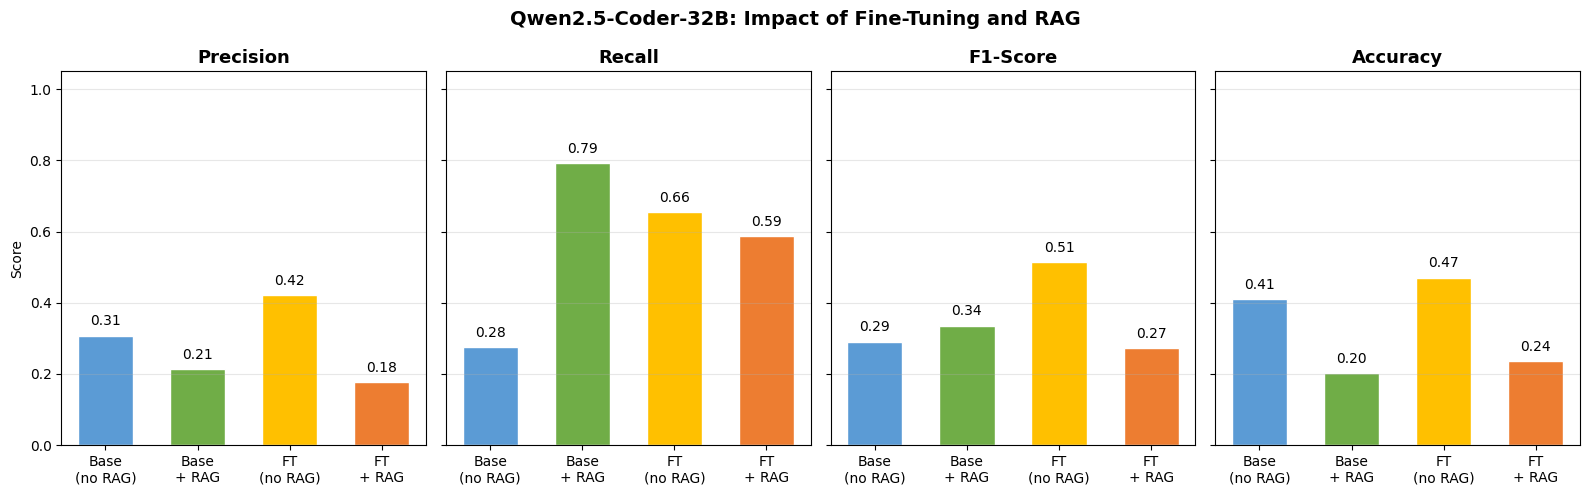

Chart 1 saved.


In [12]:
import matplotlib.pyplot as plt

CHARTS_DIR = os.path.join(RESULTS_DIR, "charts")
os.makedirs(CHARTS_DIR, exist_ok=True)

# Chart 1: All 4 configurations
configs = ["Base\n(no RAG)", "Base\n+ RAG", "FT\n(no RAG)", "FT\n+ RAG"]
metrics_list = {
    "Precision": [metrics_base_no_rag["precision"], metrics_base_rag["precision"], metrics_ft_no_rag["precision"], metrics_ft_rag["precision"]],
    "Recall": [metrics_base_no_rag["recall"], metrics_base_rag["recall"], metrics_ft_no_rag["recall"], metrics_ft_rag["recall"]],
    "F1-Score": [metrics_base_no_rag["f1_score"], metrics_base_rag["f1_score"], metrics_ft_no_rag["f1_score"], metrics_ft_rag["f1_score"]],
    "Accuracy": [metrics_base_no_rag["accuracy"], metrics_base_rag["accuracy"], metrics_ft_no_rag["accuracy"], metrics_ft_rag["accuracy"]],
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
colors = ["#5B9BD5", "#70AD47", "#FFC000", "#ED7D31"]
for ax, (metric_name, values) in zip(axes, metrics_list.items()):
    bars = ax.bar(configs, values, color=colors, edgecolor="white", width=0.6)
    ax.set_title(metric_name, fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score" if metric_name == "Precision" else "")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.2f}", ha="center", va="bottom", fontsize=10)

fig.suptitle("Qwen2.5-Coder-32B: Impact of Fine-Tuning and RAG", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "evaluation_chart.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved.")

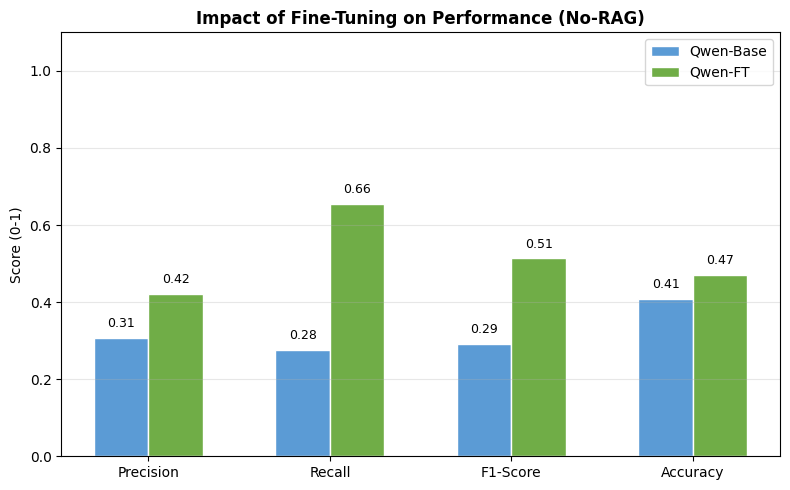

Chart 2 saved.


In [13]:
# Chart 2: Fine-Tuning Impact (Base vs FT, no RAG)
fig, ax = plt.subplots(figsize=(8, 5))
metric_names = ["Precision", "Recall", "F1-Score", "Accuracy"]
base_vals = [metrics_base_no_rag["precision"], metrics_base_no_rag["recall"], metrics_base_no_rag["f1_score"], metrics_base_no_rag["accuracy"]]
ft_vals = [metrics_ft_no_rag["precision"], metrics_ft_no_rag["recall"], metrics_ft_no_rag["f1_score"], metrics_ft_no_rag["accuracy"]]
x = np.arange(len(metric_names))
width = 0.3
bars1 = ax.bar(x - width/2, base_vals, width, label="Qwen-Base", color="#5B9BD5", edgecolor="white")
bars2 = ax.bar(x + width/2, ft_vals, width, label="Qwen-FT", color="#70AD47", edgecolor="white")
ax.set_ylabel("Score (0-1)")
ax.set_title("Impact of Fine-Tuning on Performance (No-RAG)", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "finetuning_impact.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved.")

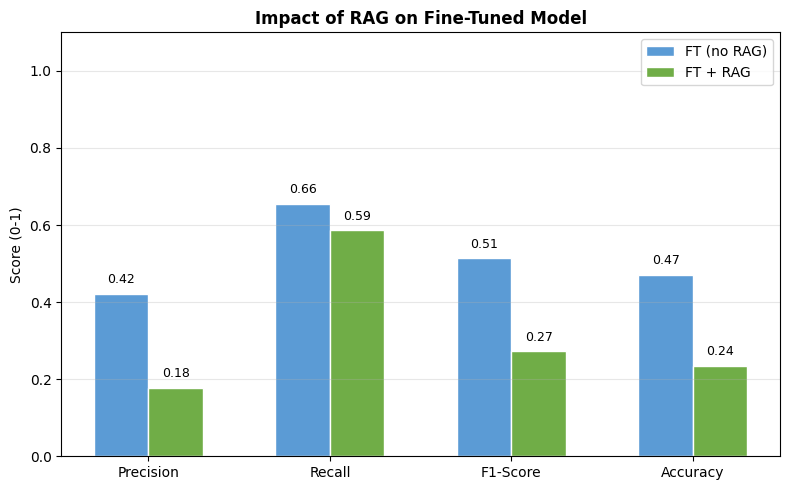

Chart 3 saved.


In [14]:
# Chart 3: RAG Impact (FT vs FT+RAG)
fig, ax = plt.subplots(figsize=(8, 5))
ft_no_rag_vals = [metrics_ft_no_rag["precision"], metrics_ft_no_rag["recall"], metrics_ft_no_rag["f1_score"], metrics_ft_no_rag["accuracy"]]
ft_rag_vals = [metrics_ft_rag["precision"], metrics_ft_rag["recall"], metrics_ft_rag["f1_score"], metrics_ft_rag["accuracy"]]
bars1 = ax.bar(x - width/2, ft_no_rag_vals, width, label="FT (no RAG)", color="#5B9BD5", edgecolor="white")
bars2 = ax.bar(x + width/2, ft_rag_vals, width, label="FT + RAG", color="#70AD47", edgecolor="white")
ax.set_ylabel("Score (0-1)")
ax.set_title("Impact of RAG on Fine-Tuned Model", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "rag_impact.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved.")

## 12. Summary & Next Steps

All results are saved under:
```
~/NotebookProjects/bboi/Mustafa_LL/results/qwen2.5-coder-32b/
├── evaluation_results.json
├── detailed_results.json
├── results_base_no_rag.json
├── results_base_rag.json
├── results_ft_no_rag.json
├── results_ft_rag.json
└── charts/
    ├── evaluation_chart.png
    ├── finetuning_impact.png
    └── rag_impact.png
```

Next: Upload these results + the notebook to the GitHub repository.

In [15]:
print("All files saved:")
for root, dirs, files in os.walk(RESULTS_DIR):
    for f in files:
        full = os.path.join(root, f)
        size = os.path.getsize(full) / 1024
        print(f"  {os.path.relpath(full, RESULTS_DIR):40s} {size:8.1f} KB")

print("\nDone! Remember to Kernel > Shutdown before leaving.")

All files saved:
  evaluation_results.json                       0.7 KB
  detailed_results.json                        50.6 KB
  results_ft_rag.json                         165.1 KB
  results_base_rag.json                       149.6 KB
  results_base_no_rag.json                    126.2 KB
  results_ft_no_rag.json                      105.8 KB
  charts/rag_impact.png                        40.6 KB
  charts/evaluation_chart.png                  65.1 KB
  charts/finetuning_impact.png                 42.8 KB

Done! Remember to Kernel > Shutdown before leaving.
